In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [26]:
df = pd.read_csv('../data/emails.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [27]:
print(df.info())
print(df['spam'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB
None
spam
0    4360
1    1368
Name: count, dtype: int64


In [28]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"subject:", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)
df.head()

,text,spam,clean_text
0,Subject: naturally irresistible your corporate...,1,naturally irresistible your corporate identity...
1,Subject: the stock trading gunslinger fanny i...,1,the stock trading gunslinger fanny is merrill ...
2,Subject: unbelievable new homes made easy im ...,1,unbelievable new homes made easy im wanting to...
3,Subject: 4 color printing special request add...,1,color printing special request additional info...
4,"Subject: do not have money , get software cds ...",1,do not have money get software cds from here s...


In [29]:
df['length'] = df['clean_text'].apply(len)

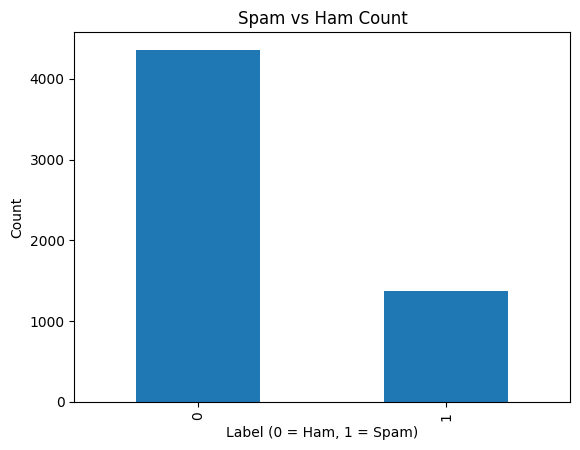

In [30]:
df['spam'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Count")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Count")
plt.show()

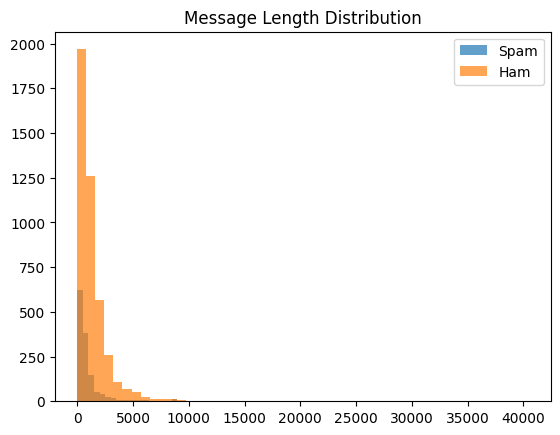

In [31]:
plt.hist(df[df['spam']==1]['length'], bins=50, alpha=0.7, label='Spam')
plt.hist(df[df['spam']==0]['length'], bins=50, alpha=0.7, label='Ham')
plt.legend()
plt.title("Message Length Distribution")
plt.show()

In [32]:
spam_words = " ".join(df[df['spam']==1]['clean_text']).split()
common_words = Counter(spam_words).most_common(10)

print("Top Spam Words:", common_words)

Top Spam Words: [('the', 8975), ('to', 8165), ('and', 6517), ('of', 5629), ('you', 4920), ('a', 4695), ('in', 3879), ('your', 3730), ('for', 3186), ('is', 2977)]


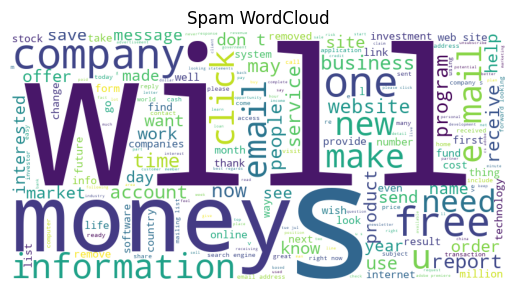

In [33]:
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate(" ".join(spam_words))

plt.imshow(wc)
plt.axis('off')
plt.title("Spam WordCloud")
plt.show()

In [34]:
cv = CountVectorizer()
X = cv.fit_transform(df['clean_text'])
y = df['spam']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [37]:
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9921465968586387


In [ ]:
sample = ["You won a free gift card click now"]
sample = cv.transform(sample)

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Spam Email 🚫")
else:
    print("Not Spam ✅")

Spam Email 🚫


In [41]:
# User se input lena
user_input = input("Enter your email message: ")

# Clean the input (same function reuse karo)
cleaned_input = clean_text(user_input)

# Transform using trained vectorizer
vector_input = cv.transform([cleaned_input])

# Prediction
prediction = model.predict(vector_input)

# Output
if prediction[0] == 1:
    print("🚫 This is a SPAM Email")
else:
    print("✅ This is NOT a Spam Email")

🚫 This is a SPAM Email
